# 📐 Notebook 1: Sample Size & Power Calculator

**Purpose:** Determine how many users you need per variant *before* the experiment runs.
Running an underpowered experiment is one of the most common mistakes in A/B testing —
you risk missing a real effect (Type II error) or stopping too early when you see noise.

### Key Concepts
| Term | Definition |
|------|-----------|
| **Alpha (α)** | False positive rate. Standard: 0.05 → 5% chance of a false win |
| **Power (1-β)** | Probability of detecting a real effect. Standard: 0.80 |
| **MDE** | Minimum Detectable Effect — smallest lift that matters to the business |
| **Baseline Rate** | Current conversion rate (pre-experiment) |

> 💡 **Rule of thumb:** Never peek at results before you have hit your required sample size.


In [1]:
import sys
sys.path.append('../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import warnings
warnings.filterwarnings('ignore')
from ab_tests import calculate_sample_size, estimate_runtime_days

plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': '#f8f9fa',
    'axes.grid': True, 'grid.alpha': 0.4, 'font.family': 'sans-serif',
    'axes.spines.top': False, 'axes.spines.right': False,
})
print("Libraries loaded successfully")

Libraries loaded successfully


---
## Scenario: New CTA Button Test on Landing Page

**Business Context:** Our landing page CTA converts at 8.0%. The design team wants
to test a high-contrast button variant. We want to detect a lift of at least 2 percentage
points (8% → 10%) before committing to a full rollout.


In [2]:
# ── EXPERIMENT PARAMETERS ─────────────────────────────────
BASELINE_RATE  = 0.080   # Current CVR (8%)
MDE            = 0.020   # Minimum lift we care about (+2pp absolute)
ALPHA          = 0.05    # Significance level (false positive rate)
POWER          = 0.80    # Statistical power (sensitivity)
DAILY_TRAFFIC  = 1200    # Total daily visitors split across both variants

result  = calculate_sample_size(BASELINE_RATE, MDE, ALPHA, POWER)
runtime = estimate_runtime_days(result['sample_size_per_variant'], DAILY_TRAFFIC)

print("=" * 55)
print("  SAMPLE SIZE REQUIREMENTS")
print("=" * 55)
for k, v in result.items():
    print(f"  {k:<38} {v}")
print()
print("=" * 55)
print("  RUNTIME ESTIMATE")
print("=" * 55)
for k, v in runtime.items():
    if k != 'warnings':
        print(f"  {k:<38} {v}")
print()
for w in runtime.get('warnings', []):
    print(f"  {w}")
if not runtime.get('warnings'):
    print("  Runtime looks healthy.")

  SAMPLE SIZE REQUIREMENTS
  sample_size_per_variant                3205
  total_sample_size                      6410
  baseline_rate                          0.08
  target_rate                            0.1
  absolute_mde                           0.02
  relative_lift_pct                      25.0
  alpha                                  0.05
  power                                  0.8
  two_tailed                             True

  RUNTIME ESTIMATE
  days_needed                            6
  weeks_needed                           0.9
  daily_traffic                          1200
  daily_per_variant                      600

  ⚠️ Runtime < 7 days — risk of novelty effect. Consider running at least 1 full week.


---
## Power Curve: Sample Size vs MDE

Smaller lifts require exponentially more traffic. Use this chart when negotiating MDE with stakeholders.

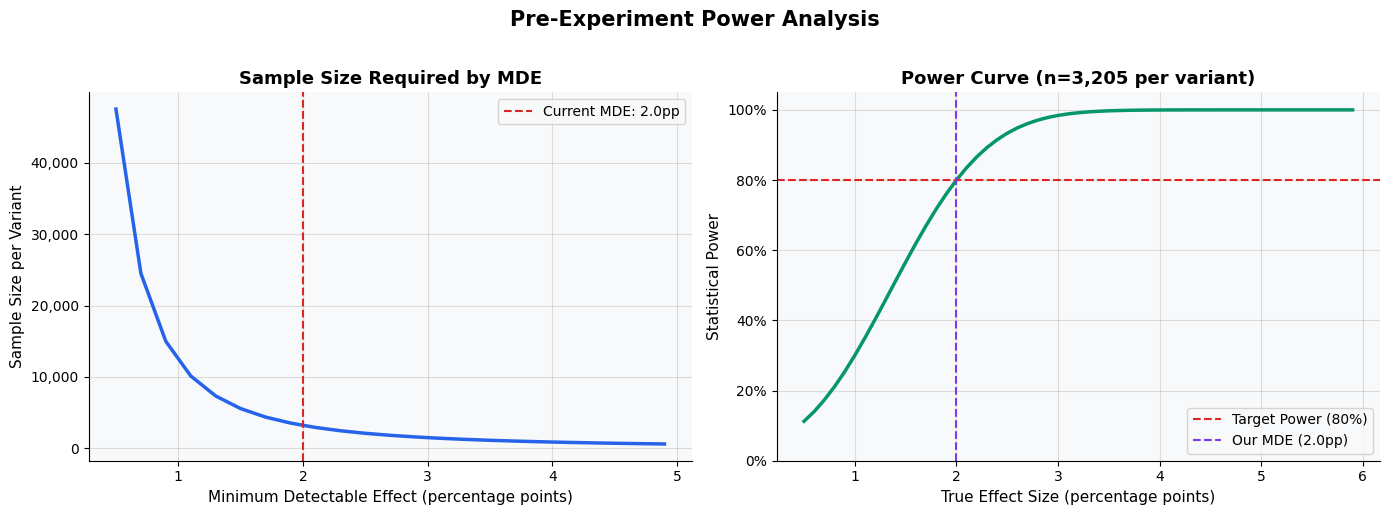

Saved to outputs/01_power_analysis.png


In [3]:
mde_range = np.arange(0.005, 0.051, 0.002)
sample_sizes = [calculate_sample_size(BASELINE_RATE, m, ALPHA, POWER)['sample_size_per_variant']
                for m in mde_range]

from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize

n_fixed = result['sample_size_per_variant']
mde_vals = np.arange(0.005, 0.06, 0.001)
powers = []
for mde in mde_vals:
    es = proportion_effectsize(BASELINE_RATE, BASELINE_RATE + mde)
    p = NormalIndPower().solve_power(effect_size=es, nobs1=n_fixed, alpha=ALPHA, alternative='two-sided')
    powers.append(min(p, 1.0))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(mde_range * 100, sample_sizes, color='#2563eb', linewidth=2.5)
axes[0].axvline(MDE * 100, color='#dc2626', linestyle='--', linewidth=1.5, label=f'Current MDE: {MDE*100:.1f}pp')
axes[0].set_xlabel('Minimum Detectable Effect (percentage points)', fontsize=11)
axes[0].set_ylabel('Sample Size per Variant', fontsize=11)
axes[0].set_title('Sample Size Required by MDE', fontsize=13, fontweight='bold')
axes[0].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{int(x):,}'))
axes[0].legend()

axes[1].plot(mde_vals * 100, powers, color='#059669', linewidth=2.5)
axes[1].axhline(0.80, color='#dc2626', linestyle='--', linewidth=1.5, label='Target Power (80%)')
axes[1].axvline(MDE * 100, color='#7c3aed', linestyle='--', linewidth=1.5, label=f'Our MDE ({MDE*100:.1f}pp)')
axes[1].set_xlabel('True Effect Size (percentage points)', fontsize=11)
axes[1].set_ylabel('Statistical Power', fontsize=11)
axes[1].set_title(f'Power Curve (n={n_fixed:,} per variant)', fontsize=13, fontweight='bold')
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[1].legend(); axes[1].set_ylim(0, 1.05)

plt.suptitle('Pre-Experiment Power Analysis', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/01_power_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to outputs/01_power_analysis.png")

---
## Pre-Launch Checklist

| Check | Status |
|-------|--------|
| Sample size calculated before launch | ✅ |
| Runtime is 7–60 days | ✅ |
| MDE approved by business stakeholders | ✅ |
| Alpha and power locked before launch | ✅ |

**Next step → Notebook 02: Data Validation & Sanity Checks**
